Explain diff between gml and mat dataset

In [ ]:
import igraph as ig
import scipy.io as sio
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from torch_geometric.data import Data
import torch
from torch_geometric.utils import to_networkx, from_networkx, from_scipy_sparse_matrix, to_undirected

In [33]:
def diff(name1, name2):
    igG = ig.Graph.Read_GML(f"./small_gml/{name1}.gml")
    G = igG.to_networkx()
    data1 = from_networkx(G)
    
    data_dir = f"./small_mat/{name2}.mat"
    net = sio.loadmat(data_dir)
    edge_index, _ = from_scipy_sparse_matrix(net["net"])
    data2 = Data(edge_index=edge_index, num_nodes=torch.max(edge_index).item() + 1)
    
    ei1 = set(map(tuple, data1.edge_index.T.tolist()))
    ei2 = set(map(tuple, data2.edge_index.T.tolist()))
    print("data1", len(ei1))
    print("data2", len(ei2))
    print("inter", len(ei1.intersection(ei2)))
    return data1, data2

In [34]:
diff('power', 'Power')

data1 13188
data2 13188
inter 13188


(Data(edge_index=[2, 13188], id=[4941], edge_id=[13188], edge__igraph_index=[13188], citation='['D.J. Watts and S.H. Strogatz, "Collective dynamics of \'small-world\' networks." Nature 393, 440-442 (1998)., http://www.nature.com/nature/journal/v393/n6684/abs/393440a0.html']', description='A network representing the Western States Power Grid of the United States, in which nodes are transforms or power relay points and two nodes are connected if a power line runs between them.', name='power', tags='Technological, Power grid, Unweighted', url='http://www-personal.umich.edu/~mejn/netdata/', num_nodes=4941),
 Data(edge_index=[2, 13188], num_nodes=4941))

In [35]:
data1, data2 = diff('netscience', 'NS')

data1 5484
data2 5484
inter 1982


/tmp/ipykernel_74691/240679784.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  nx.draw(G, node_size=20, pos=pos, node_color=node_colors, cmap=plt.cm.get_cmap('jet', len(commu)))


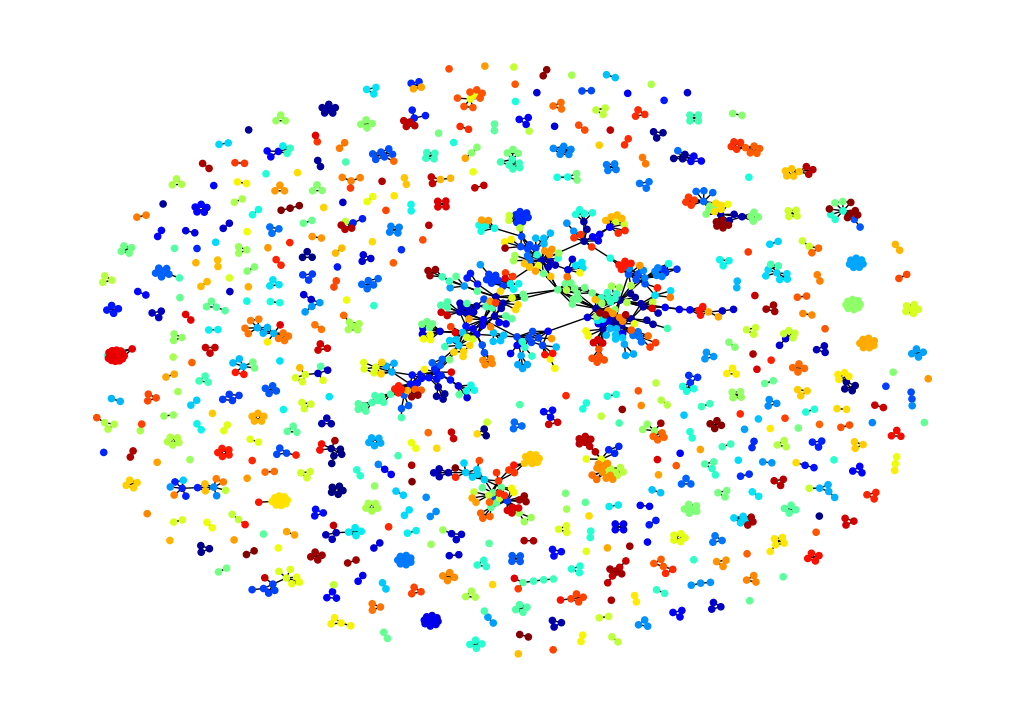

torch.Size([2, 5484])


In [37]:
if hasattr(data1, "_pos"):
    pos = {}
    for i, p in enumerate(data1._pos):
        x, y = p.split(", ")
        pos[i] = np.array([float(x), float(y)])
else:
    pos = nx.spring_layout(G)
    
def plot(data, commu, title= ""):
    G = to_networkx(data, to_undirected=True)
    color_map = {}
    for i, community in enumerate(commu):
        for node in community:
            color_map[node] = i
    node_colors = [color_map[node] for node in G.nodes()]
    plt.figure(figsize=(10, 7))
    nx.draw(G, node_size=20, pos=pos, node_color=node_colors, cmap=plt.cm.get_cmap('jet', len(commu)))
    # nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')
    plt.title(title)
    plt.show()
    print(data.edge_index.shape)
commu = []
for c in range(data1.num_nodes):
    commu.append({c})
plot(data1, commu)

/tmp/ipykernel_74691/240679784.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  nx.draw(G, node_size=20, pos=pos, node_color=node_colors, cmap=plt.cm.get_cmap('jet', len(commu)))


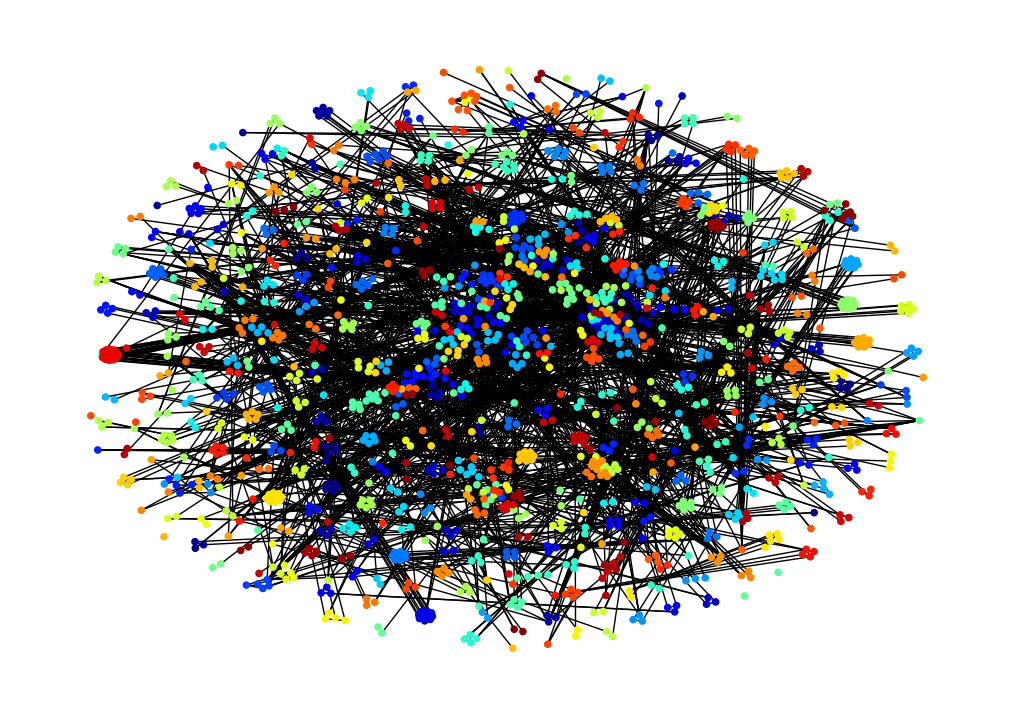

torch.Size([2, 5484])


In [39]:
commu = []
for c in range(data2.num_nodes):
    commu.append({c})
plot(data2, commu)